# Prédiction

# 0. Import des données

## Import des ibraries

In [1]:
import pandas as pd
import os
import glob
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

%matplotlib inline

## Chargement du dataset SILVER

In [ ]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"

try:
    path_dataset = next(repertoire_data_processed.glob("02_dataset_silver.csv"))
    print(f"Fichier trouvé : {path_dataset}")
    
    # Lecture
    df = pd.read_csv(path_dataset)
except StopIteration:
    print("Erreur : Le fichier '02_dataset_silver.csv' est introuvable dans le dossier.")

AttributeError: 'str' object has no attribute 'glob'

# 1. Préparation des données

In [3]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [4]:
col_removed = ['taux_chomage_homme_insee',
       'taux_chomage_femme_insee', 'taux_chomage_15_24_insee',
       'taux_chomage_25_49_insee', 'taux_chomage_50_plus_insee',
       'demandeur_total_abcd_total', 'demandeur_homme_abcd_total',
       'demandeur_femme_abcd_total', 'demandeur_total_abcd_moins25',
       'demandeur_total_abcd_2549', 'demandeur_total_abcd_plus50',
       'demandeur_homme_abcd_moins25', 'demandeur_homme_abcd_2549',
       'demandeur_homme_abcd_plus50', 'demandeur_femme_abcd_moins25',
       'demandeur_femme_abcd_2549', 'demandeur_femme_abcd_plus50',
       'taux_chomage_ocde']

In [5]:
df = df.drop(columns=col_removed)

In [6]:
df

,date,taux_chomage_total_insee,population_active,pib,ict,nb_interimaires,taux_euribor_3m,mro,taux_change_eur_dollar,ipc,...,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,indicateur_climat_affaires_diff_lag,taux_euribor_3m_diff,mro_diff,taux_change_eur_dollar_var,is_covid
0,2000-01-01,9.1,27313657.00,480413.0,64.0,626034.321717,3.542300,3.250000,0.968600,1.466667,...,1.723014,1.345448,0.389039,-4.1,-4.3,5.9,0.112500,0.416667,-0.050268,0
1,2000-04-01,8.7,27345643.25,485729.0,64.8,654917.645198,4.263000,3.916667,0.931467,1.433333,...,1.754474,1.977185,3.053740,6.0,0.3,-4.3,0.720700,0.666667,-0.038337,0
2,2000-07-01,8.4,27377629.50,489490.0,65.1,665404.780110,4.737600,4.250000,0.897133,1.900000,...,1.901287,1.861366,-4.481288,-1.1,1.4,0.3,0.474600,0.333333,-0.036859,0
3,2000-10-01,8.0,27409615.75,492460.0,65.9,651193.119730,5.024167,4.250000,0.880200,1.900000,...,1.492307,1.966656,4.852425,1.0,-3.9,1.4,0.286567,0.000000,-0.018875,0
4,2001-01-01,7.8,27441602.00,495040.0,66.6,676865.312560,4.745033,4.250000,0.912433,1.300000,...,1.376954,1.819251,-1.117994,-1.4,-1.1,-3.9,-0.279133,0.000000,0.036620,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,2024-07-01,7.4,31859898.00,655027.0,110.1,726325.294868,3.555367,4.050000,1.103700,1.733333,...,-0.300908,-0.160190,5.413804,-1.5,-2.2,-0.8,-0.252833,-0.366667,0.025902,0
99,2024-10-01,7.3,31859898.00,654734.0,111.3,713974.330136,2.996500,3.316667,1.061100,1.266667,...,-0.552588,-0.381298,-6.641302,-2.1,-2.4,-2.2,-0.558867,-0.733333,-0.038597,0
100,2025-01-01,7.5,31859898.00,655389.0,112.3,710419.927973,2.556833,2.900000,1.053967,1.100000,...,-0.384802,-0.391827,2.398082,-0.1,1.6,-2.4,-0.439667,-0.416667,-0.006723,0
101,2025-04-01,7.6,31859898.00,657523.0,112.2,709895.580836,2.107700,2.316667,1.147733,0.833333,...,-0.447721,-0.191777,-2.470248,1.9,-0.6,1.6,-0.449133,-0.583333,0.088965,0


In [7]:
df.columns

Index(['date', 'taux_chomage_total_insee', 'population_active', 'pib', 'ict',
       'nb_interimaires', 'taux_euribor_3m', 'mro', 'taux_change_eur_dollar',
       'ipc', 'isj', 'ipc_energie_only', 'nb_defaillances_entreprise',
       'nb_offres_france_travail', 'indicateur_confiance_menage',
       'indicateur_climat_affaires', 'indicateur_climat_emploi',
       'indicateur_retournement_conjoncturel', 'population_active_var',
       'nb_offres_france_travail_var', 'nb_defaillances_entreprise_var',
       'nb_interimaires_var', 'pib_logdiff', 'pib_logdiff_lag', 'ipc_yoy',
       'ipc_energie_only_yoy', 'ict_var', 'isj_diff',
       'taux_chomage_total_insee_diff', 'taux_chomage_ocde_diff',
       'indicateur_confiance_menage_zscore',
       'indicateur_climat_affaires_zscore', 'indicateur_climat_emploi_zscore',
       'indicateur_confiance_menage_diff', 'indicateur_climat_emploi_diff',
       'indicateur_climat_affaires_diff',
       'indicateur_climat_affaires_diff_lag', 'taux_euribor_

## Matrice de corrélation

In [8]:
# 1. Calcul de la corrélation (sur les colonnes numériques uniquement)
# On obtient une Série dont l'index est le nom des variables
df_corr_chomage_insee = df.select_dtypes(include=[np.number]).corr()['taux_chomage_total_insee']

# 2. Transformation en DataFrame
# reset_index() bascule les noms des variables de l'index vers une colonne
df_corr_chomage_insee = df_corr_chomage_insee.reset_index()
df_corr_chomage_insee.columns = ['Variable', 'Coefficient_Correlation']

# 4. (Optionnel) Tri pour voir les corrélations les plus fortes en haut
df_corr_chomage_insee = df_corr_chomage_insee.sort_values(by='Variable', ascending=True)

# Affichage du résultat
print(df_corr_chomage_insee.head(60))

                                Variable  Coefficient_Correlation
3                                    ict                -0.129615
25                               ict_var                -0.255614
14            indicateur_climat_affaires                -0.145626
34       indicateur_climat_affaires_diff                 0.294724
35   indicateur_climat_affaires_diff_lag                 0.205423
30     indicateur_climat_affaires_zscore                -0.145626
15              indicateur_climat_emploi                -0.247014
33         indicateur_climat_emploi_diff                 0.272670
31       indicateur_climat_emploi_zscore                -0.247014
13           indicateur_confiance_menage                -0.098678
32      indicateur_confiance_menage_diff                 0.204265
29    indicateur_confiance_menage_zscore                -0.098678
16  indicateur_retournement_conjoncturel                 0.153477
8                                    ipc                -0.596794
10        

In [9]:
col_removed2 = [
    'ict',
    'indicateur_climat_affaires',
    'indicateur_climat_affaires_diff_lag',
    'indicateur_climat_affaires_zscore',
    'indicateur_climat_emploi',
    'indicateur_climat_emploi_zscore',
    'indicateur_confiance_menage',
    'indicateur_confiance_menage_zscore',
    'ipc_energie_only_yoy',
    'ipc_yoy',
    'isj_diff',
    'mro_diff',
    'nb_defaillances_entreprise_var',
    'nb_interimaires_var',
    'nb_offres_france_travail_var',
    'pib',
    'pib_logdiff_lag',
    'population_active',
    'taux_change_eur_dollar_var',
    'taux_chomage_ocde_diff',
    'taux_chomage_total_insee_diff',
    'taux_euribor_3m_diff' 
]

In [10]:
df_ml = df.drop(columns=col_removed2)

In [11]:
df_ml

,date,taux_chomage_total_insee,nb_interimaires,taux_euribor_3m,mro,taux_change_eur_dollar,ipc,isj,ipc_energie_only,nb_defaillances_entreprise,nb_offres_france_travail,indicateur_retournement_conjoncturel,population_active_var,pib_logdiff,ict_var,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,is_covid
0,2000-01-01,9.1,626034.321717,3.542300,3.250000,0.968600,1.466667,0.866667,13.000000,12348.0,831900.0,1.0,0.001572,0.009695,0.009464,0.389039,-4.1,-4.3,0
1,2000-04-01,8.7,654917.645198,4.263000,3.916667,0.931467,1.433333,1.100000,12.833333,10605.0,875300.0,1.0,0.001171,0.011005,0.012500,3.053740,6.0,0.3,0
2,2000-07-01,8.4,665404.780110,4.737600,4.250000,0.897133,1.900000,1.233333,14.066667,9025.0,822700.0,1.0,0.001170,0.007713,0.004630,-4.481288,-1.1,1.4,0
3,2000-10-01,8.0,651193.119730,5.024167,4.250000,0.880200,1.900000,1.366667,11.133333,11990.0,691600.0,0.9,0.001168,0.006049,0.012289,4.852425,1.0,-3.9,0
4,2001-01-01,7.8,676865.312560,4.745033,4.250000,0.912433,1.300000,1.433333,0.666667,9060.0,805000.0,0.6,0.001167,0.005225,0.010622,-1.117994,-1.4,-1.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,2024-07-01,7.4,726325.294868,3.555367,4.050000,1.103700,1.733333,1.533333,1.866667,13756.0,944500.0,-0.8,0.000000,0.003658,0.003646,5.413804,-1.5,-2.2,0
99,2024-10-01,7.3,713974.330136,2.996500,3.316667,1.061100,1.266667,1.400000,-0.500000,18405.0,789700.0,-0.9,0.000000,-0.000447,0.010899,-6.641302,-2.1,-2.4,0
100,2025-01-01,7.5,710419.927973,2.556833,2.900000,1.053967,1.100000,1.333333,-3.233333,18156.0,828800.0,-0.6,0.000000,0.001000,0.008985,2.398082,-0.1,1.6,0
101,2025-04-01,7.6,709895.580836,2.107700,2.316667,1.147733,0.833333,1.200000,-7.500000,17295.0,804900.0,-0.2,0.000000,0.003251,-0.000890,-2.470248,1.9,-0.6,0


## Création des variables features et target

In [12]:
X = df_ml.drop(["taux_chomage_total_insee", "date"], axis=1)
y = df_ml['taux_chomage_total_insee']

In [13]:
X

,nb_interimaires,taux_euribor_3m,mro,taux_change_eur_dollar,ipc,isj,ipc_energie_only,nb_defaillances_entreprise,nb_offres_france_travail,indicateur_retournement_conjoncturel,population_active_var,pib_logdiff,ict_var,indicateur_confiance_menage_diff,indicateur_climat_emploi_diff,indicateur_climat_affaires_diff,is_covid
0,626034.321717,3.542300,3.250000,0.968600,1.466667,0.866667,13.000000,12348.0,831900.0,1.0,0.001572,0.009695,0.009464,0.389039,-4.1,-4.3,0
1,654917.645198,4.263000,3.916667,0.931467,1.433333,1.100000,12.833333,10605.0,875300.0,1.0,0.001171,0.011005,0.012500,3.053740,6.0,0.3,0
2,665404.780110,4.737600,4.250000,0.897133,1.900000,1.233333,14.066667,9025.0,822700.0,1.0,0.001170,0.007713,0.004630,-4.481288,-1.1,1.4,0
3,651193.119730,5.024167,4.250000,0.880200,1.900000,1.366667,11.133333,11990.0,691600.0,0.9,0.001168,0.006049,0.012289,4.852425,1.0,-3.9,0
4,676865.312560,4.745033,4.250000,0.912433,1.300000,1.433333,0.666667,9060.0,805000.0,0.6,0.001167,0.005225,0.010622,-1.117994,-1.4,-1.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,726325.294868,3.555367,4.050000,1.103700,1.733333,1.533333,1.866667,13756.0,944500.0,-0.8,0.000000,0.003658,0.003646,5.413804,-1.5,-2.2,0
99,713974.330136,2.996500,3.316667,1.061100,1.266667,1.400000,-0.500000,18405.0,789700.0,-0.9,0.000000,-0.000447,0.010899,-6.641302,-2.1,-2.4,0
100,710419.927973,2.556833,2.900000,1.053967,1.100000,1.333333,-3.233333,18156.0,828800.0,-0.6,0.000000,0.001000,0.008985,2.398082,-0.1,1.6,0
101,709895.580836,2.107700,2.316667,1.147733,0.833333,1.200000,-7.500000,17295.0,804900.0,-0.2,0.000000,0.003251,-0.000890,-2.470248,1.9,-0.6,0


In [14]:
y

0      9.1
1      8.7
2      8.4
3      8.0
4      7.8
      ... 
98     7.4
99     7.3
100    7.5
101    7.6
102    7.7
Name: taux_chomage_total_insee, Length: 103, dtype: float64

# 2. Feature Selection

## a. LASSO

In [20]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Lasso nécessite des données mises à l'échelle (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entraînement avec validation croisée pour trouver le meilleur alpha
lasso = LassoCV(cv=3).fit(X_scaled, y)

# Extraction des importances (valeur absolue des coefficients)
lasso_importance = pd.Series(abs(lasso.coef_), index=X.columns).sort_values(ascending=False)

In [21]:
print(lasso_importance)

nb_interimaires                         0.421574
taux_euribor_3m                         0.352907
isj                                     0.296795
is_covid                                0.207689
pib_logdiff                             0.198377
nb_defaillances_entreprise              0.152063
mro                                     0.102292
indicateur_retournement_conjoncturel    0.081127
indicateur_climat_affaires_diff         0.077497
indicateur_confiance_menage_diff        0.051687
ipc_energie_only                        0.049357
nb_offres_france_travail                0.016010
population_active_var                   0.015564
ict_var                                 0.011668
taux_change_eur_dollar                  0.007544
indicateur_climat_emploi_diff           0.005252
ipc                                     0.000000
dtype: float64


## b. Random Forest

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extraction des scores d'importance
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

In [24]:
print(rf_importance)

isj                                     0.329303
taux_euribor_3m                         0.129831
nb_interimaires                         0.127577
nb_defaillances_entreprise              0.076498
ipc                                     0.068142
taux_change_eur_dollar                  0.067866
mro                                     0.039795
nb_offres_france_travail                0.031970
indicateur_retournement_conjoncturel    0.030568
ipc_energie_only                        0.025307
population_active_var                   0.021114
ict_var                                 0.012737
indicateur_climat_affaires_diff         0.011995
pib_logdiff                             0.009932
indicateur_climat_emploi_diff           0.009527
indicateur_confiance_menage_diff        0.006419
is_covid                                0.001419
dtype: float64


## c. SelectKBest

In [27]:
from sklearn.feature_selection import SelectKBest, f_regression


# 2. Configuration de SelectKBest
# k='all' permet de calculer les scores pour toutes les colonnes
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

# 3. Récupération des scores (plus le score F est haut, plus la variable est utile)
skb_results = pd.DataFrame({
    'Variable': X.columns,
    'Score_F': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values(by='Score_F', ascending=False)

print(skb_results.head(10))

                           Variable    Score_F       P_Value
5                               isj  63.031242  2.912798e-12
4                               ipc  55.871936  2.875772e-11
1                   taux_euribor_3m  39.687858  7.845601e-09
2                               mro  32.828028  1.045489e-07
0                   nb_interimaires  30.168759  2.968225e-07
8          nb_offres_france_travail  29.029862  4.674531e-07
7        nb_defaillances_entreprise  16.808273  8.373894e-05
3            taux_change_eur_dollar  10.430380  1.673019e-03
15  indicateur_climat_affaires_diff   9.607622  2.510754e-03
10            population_active_var   8.980560  3.433822e-03


# Prédictions

## Feature selection avec LASSO

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# Création des lags pour toutes les variables
df['chomage_lag1'] = df['taux_chomage_total_insee'].shift(1)
variables = [
    'ict_var', 'indicateur_climat_affaires_diff', 'indicateur_climat_emploi_diff',
    'indicateur_confiance_menage_diff', 'indicateur_retournement_conjoncturel',
    'ipc_yoy', 'isj_diff', 'taux_euribor_3m_diff', 'nb_interimaires_var',
    'nb_offres_france_travail_var', 'pib_logdiff', 'population_active_var'
]

for v in variables:
    if v in df.columns:
        df[f'{v}_lag1'] = df[v].shift(1)

# Liste des colonnes candidates pour l'IA
potential_features = [c for c in df.columns if '_lag1' in c] + ['is_covid']
target = 'taux_chomage_total_insee'

# On aligne les données (suppression des NaNs dus aux décalages)
df_ml = df.dropna(subset=potential_features + [target]).copy()

# --- ÉTAPE CLÉ : FEATURE SELECTION (LASSO) ---
# Le Lasso va automatiquement identifier les variables qui ont un impact réel
scaler_pre = StandardScaler()
X_for_lasso = scaler_pre.fit_transform(df_ml[potential_features])
lasso = LassoCV(cv=5, random_state=42).fit(X_for_lasso, df_ml[target])

# LASSO RESULTS : On crée un dictionnaire pour faciliter la manipulation
# Créer une liste de tuples (nom, coefficient)
features_scores = list(zip(potential_features, lasso.coef_))

# Trier la liste par la valeur absolue du coefficient (du plus grand au plus petit)
features_scores.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"{'Variable (Classée par importance)':<45} | {'Score Lasso':<12}")
print("-" * 60)

for name, coef in features_scores:
    print(f"{name:<45} | {coef:>12.4f}")

# On ne garde que les variables dont le coefficient n'est pas nul
selected_features = [f for f, c in zip(potential_features, lasso.coef_) if abs(c) > 0.001]
print(f"Variables sélectionnées par l'IA : {selected_features}")
"""
# 2. ENTRAÎNEMENT DU MODÈLE FINAL (RIDGE)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
model.fit(df_ml[selected_features], df_ml[target])"""

Variable (Classée par importance)             | Score Lasso 
------------------------------------------------------------
chomage_lag1                                  |       0.9584
pib_logdiff_lag1                              |      -0.1513
nb_interimaires_var_lag1                      |       0.1174
indicateur_retournement_conjoncturel_lag1     |      -0.0696
taux_euribor_3m_diff_lag1                     |      -0.0662
population_active_var_lag1                    |       0.0529
nb_offres_france_travail_var_lag1             |      -0.0490
is_covid                                      |      -0.0472
indicateur_confiance_menage_diff_lag1         |       0.0187
indicateur_climat_emploi_diff_lag1            |      -0.0185
indicateur_climat_affaires_diff_lag1          |      -0.0095
isj_diff_lag1                                 |      -0.0017
ict_var_lag1                                  |       0.0000
ipc_yoy_lag1                                  |      -0.0000
Variables sélectionnées 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


ChômageT​=(0.958×ChômageT−1​)+(−0.151×PIBT−1​)+(0.053×PopActiveT−1​)+…

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# --- PRÉPARATION DES DONNÉES ---
# (On suppose que ton df a déjà les colonnes lag1 créées précédemment)

# On ne garde que la "Crème de la Crème" identifiée par ton Lasso
final_features = [
    'chomage_lag1', 
    'pib_logdiff_lag1', 
    'nb_interimaires_var_lag1', 
    'indicateur_retournement_conjoncturel_lag1', 
    'population_active_var_lag1', 
    'is_covid'
]

target = 'taux_chomage_total_insee'
df_final = df.dropna(subset=final_features + [target])

# Entraînement du modèle de production
model_prod = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
model_prod.fit(df_final[final_features], df_final[target])

# Vérification rapide des coefficients pour être sûr du sens
coefs = model_prod.named_steps['ridge'].coef_
print("Poids du modèle :", dict(zip(final_features, coefs)))

Poids du modèle : {'chomage_lag1': np.float64(0.9689953277040837), 'pib_logdiff_lag1': np.float64(-0.1949916602116943), 'nb_interimaires_var_lag1': np.float64(0.10600551348264001), 'indicateur_retournement_conjoncturel_lag1': np.float64(-0.10226145314413346), 'population_active_var_lag1': np.float64(0.06390730816192194), 'is_covid': np.float64(-0.05786033590575739)}


In [46]:
# --- CALCUL AUTOMATIQUE DE LA DYNAMIQUE 2025 ---
# On calcule la moyenne des 4 derniers trimestres pour chaque variable clé
moyennes_2025 = {f: df_final[f].tail(4).mean() for f in final_features}

# 2. SCÉNARIO STABLE : "Continuité de la tendance"
hypo_middle = moyennes_2025.copy()
hypo_middle['is_covid'] = 0  # On s'assure que le facteur crise est éteint

# Affichage pour vérification
print("Hypothèses Middle (moyennes réelles) :")
for k, v in hypo_middle.items():
    if k != 'target_lag1': # On ne print pas le lag qui change tout le temps
        print(f" - {k}: {v:.6f}")

Hypothèses Middle (moyennes réelles) :
 - chomage_lag1: 7.450000
 - pib_logdiff_lag1: 0.001865
 - nb_interimaires_var_lag1: -0.008476
 - indicateur_retournement_conjoncturel_lag1: -0.625000
 - population_active_var_lag1: 0.000000
 - is_covid: 0.000000


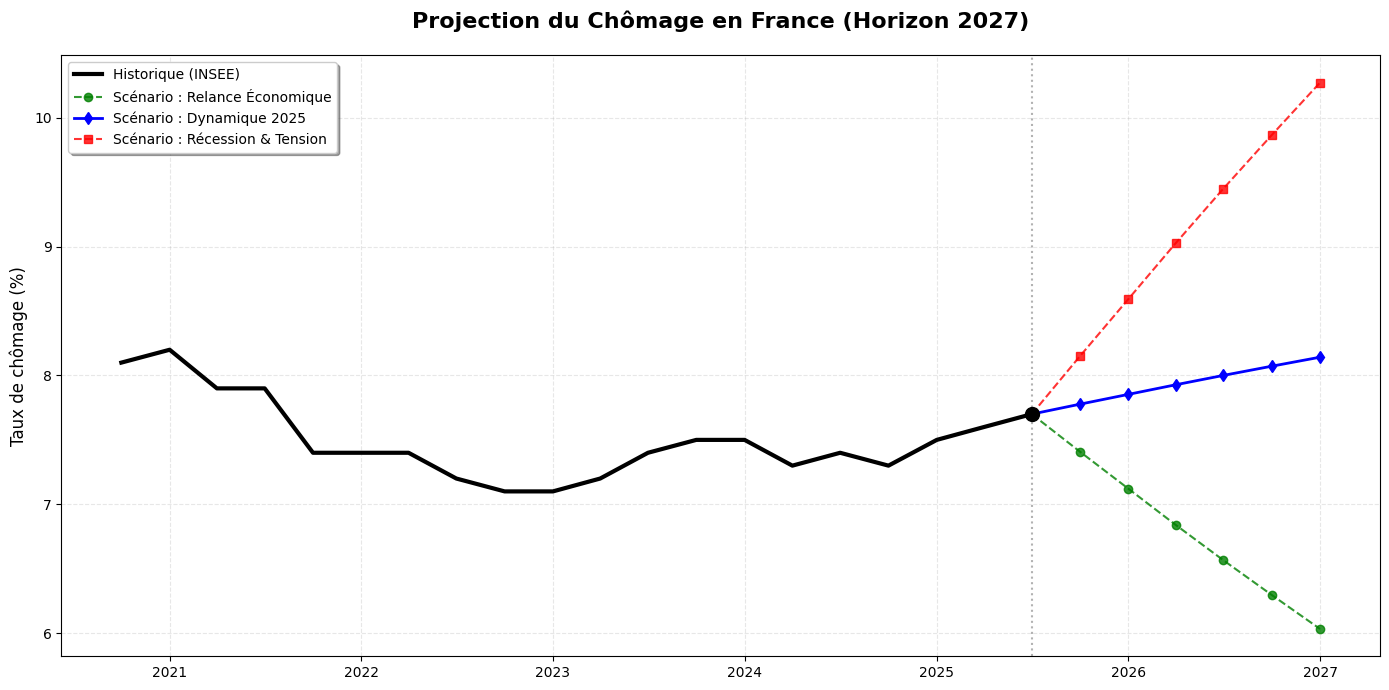

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. --- RÉCUPÉRATION DU POINT D'ANCRAGE (Dernière donnée réelle) ---
last_date = df['date'].iloc[-1]
start_rate = df[target].iloc[-1]

# On crée une plage de dates qui INCLUT la dernière date réelle pour la connexion
# periods=7 car : 1 point d'ancrage + 6 points de prévision
dates_projection = pd.date_range(start=last_date, periods=7, freq='QS')

# 2. --- FONCTION DE SIMULATION AJUSTÉE ---
def simuler_2026_fixed(hypo_base, start_val, model, features):
    # On initialise la liste avec la valeur RÉELLE (l'ancre)
    results = [start_val] 
    current_val = start_val
    
    # On ne boucle que 6 fois pour les prédictions suivantes
    for _ in range(6):
        X = pd.DataFrame([hypo_base])
        X['chomage_lag1'] = current_val 
        X = X[features]
        pred = model.predict(X)[0]
        results.append(pred)
        current_val = pred
    return results

# 3. --- PARAMÈTRES DES SCÉNARIOS (Inchangés mais nettoyés) ---

# 1. HYPOTHÈSE HAUTE : À chaque trimestre, la croissance "grignote" l'inertie du chômage.
hypo_opt = {
    'chomage_lag1': start_rate, 
    'pib_logdiff_lag1': 0.012,        # Croissance forte (+1.2% / trim)
    'nb_interimaires_var_lag1': -0.02, # Moins de précarité (selon ton coef Lasso +0.09)
    'indicateur_retournement_conjoncturel_lag1': 1.0, # Conjoncture au vert
    'population_active_var_lag1': -0.001, # Moins de nouveaux entrants
    'is_covid': 0
}

# 2. HYPOTHÈSE STABLE : "scénario de "continuité" (ou status quo) se base généralement sur la moyenne glissante des 4 derniers trimestres.
hypo_middle = {
    'chomage_lag1': start_rate,
    'pib_logdiff_lag1': 0.001865,       # Croissance très faible (+0,01% / trim)
    'nb_interimaires_var_lag1': -0.008476, # Légère baisse de l'intérim subi
    'indicateur_retournement_conjoncturel_lag1': -0.625000, # stable
    'population_active_var_lag1': 0.000000, #  Démographie stable
    'is_covid': 0
}
# 3. HYPOTHÈSE BASSE : Le chômage monte car l'économie ne crée pas assez de jobs pour absorber les nouveaux arrivants.
hypo_pess = {
    'chomage_lag1': start_rate,
    'pib_logdiff_lag1': -0.003,       # Récession (-0.3% / trim)
    'nb_interimaires_var_lag1': 0.03, # Explosion de l'intérim subi
    'indicateur_retournement_conjoncturel_lag1': -1.5, # Alerte retournement
    'population_active_var_lag1': 0.004, # Forte pression démographique
    'is_covid': 0
}

# 4. --- LANCEMENT DES SIMULATIONS ---
curve_opt = simuler_2026_fixed(hypo_opt, start_rate, model_prod, final_features)
curve_mid = simuler_2026_fixed(hypo_middle, start_rate, model_prod, final_features)
curve_pess = simuler_2026_fixed(hypo_pess, start_rate, model_prod, final_features)

# 5. --- GRAPHIQUE FINAL ---
plt.figure(figsize=(14, 7))

# Historique (on prend un peu plus de recul pour la perspective)
plt.plot(df['date'].tail(20), df[target].tail(20), label='Historique (INSEE)', color='black', linewidth=3)

# Les 3 scénarios partant du même point
plt.plot(dates_projection, curve_opt, 'g--o', label='Scénario : Relance Économique', alpha=0.8)
plt.plot(dates_projection, curve_mid, 'b-d', label='Scénario : Dynamique 2025', linewidth=2)
plt.plot(dates_projection, curve_pess, 'r--s', label='Scénario : Récession & Tension', alpha=0.8)

# Point de jonction visuel
plt.scatter(last_date, start_rate, color='black', s=100, zorder=5) 

plt.title("Projection du Chômage en France (Horizon 2027)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Taux de chômage (%)", fontsize=12)
plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.6) # Ligne de démarcation
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

--- RÉSULTATS DU TEST SUR DONNÉES EXISTANTES ---
Erreur Moyenne (MAE) : 0.142 points
Erreur Moyenne (MSE) : 0.032 points
Erreur Moyenne (RMSE) : 0.178 points
Précision (R²) : 0.592


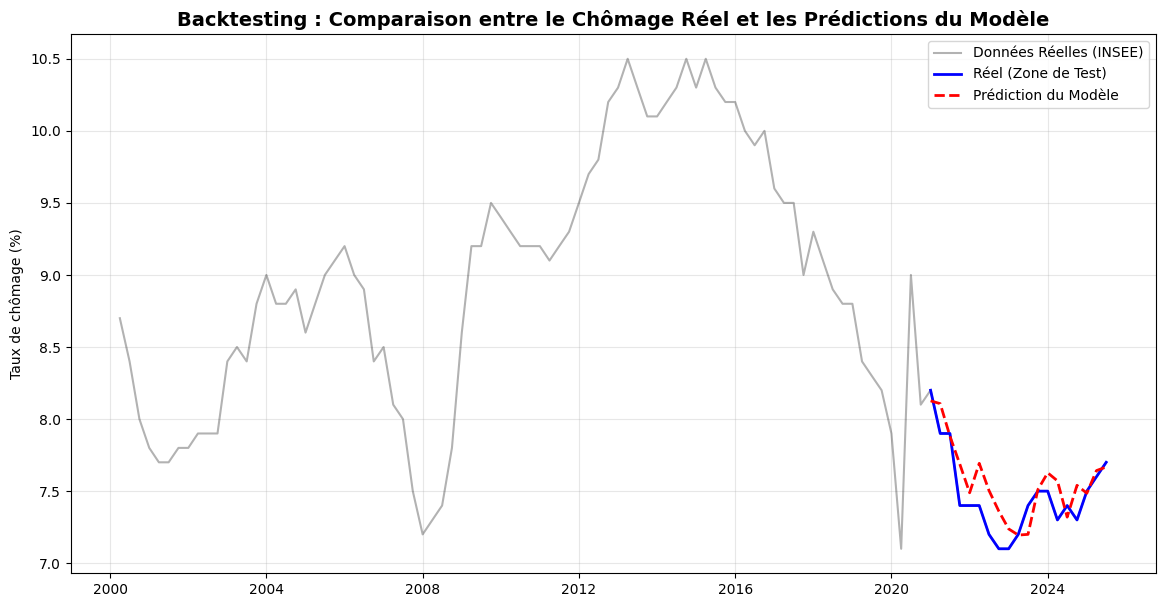

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Variables sélectionnées (Top Lasso)
final_features = [
    'chomage_lag1', 
    'pib_logdiff_lag1', 
    'nb_interimaires_var_lag1', 
    'indicateur_retournement_conjoncturel_lag1', 
    'population_active_var_lag1', 
    'is_covid'
]
target = 'taux_chomage_total_insee'

# Nettoyage des NaNs
df_test = df.dropna(subset=final_features + [target]).copy()

# --- ÉTAPE CLÉ : LE SPLIT CHRONOLOGIQUE --15
# On s'entraîne sur le passé et on teste sur les dernières années existantes
# On coupe par exemple à 85% du dataset
split_idx = int(len(df_test) * 0.82)

train = df_test.iloc[:split_idx]
test = df_test.iloc[split_idx:]

# 2. ENTRAÎNEMENT DU MODÈLE
model_backtest = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
model_backtest.fit(train[final_features], train[target])

# 3. PRÉDICTION SUR LES DONNÉES EXISTANTES (Zone Test)
# On utilise les données du test pour voir si le modèle "devine" bien le chômage connu
predictions = model_backtest.predict(test[final_features])

# 4. ÉVALUATION DES PERFORMANCES
mae = mean_absolute_error(test[target], predictions)
mse = mean_squared_error(test[target], predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test[target], predictions)

print(f"--- RÉSULTATS DU TEST SUR DONNÉES EXISTANTES ---")
print(f"Erreur Moyenne (MAE) : {mae:.3f} points")
print(f"Erreur Moyenne (MSE) : {mse:.3f} points")
print(f"Erreur Moyenne (RMSE) : {rmse:.3f} points")
print(f"Précision (R²) : {r2:.3f}")

# 5. VISUALISATION (Le comparatif Réel vs Prédiction)
plt.figure(figsize=(14, 7))

# Courbe réelle complète (en noir/gris)
plt.plot(df_test['date'], df_test[target], label='Données Réelles (INSEE)', color='black', alpha=0.3)

# Focus sur la zone de test (en bleu)
plt.plot(test['date'], test[target], label='Réel (Zone de Test)', color='blue', linewidth=2)

# Prédiction du modèle (en rouge pointillé)
plt.plot(test['date'], predictions, label='Prédiction du Modèle', color='red', linestyle='--', linewidth=2)

plt.title("Backtesting : Comparaison entre le Chômage Réel et les Prédictions du Modèle", fontsize=14, fontweight='bold')
plt.ylabel("Taux de chômage (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [65]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. Configuration du découpage (5 plis / folds)
tscv = TimeSeriesSplit(n_splits=5)

# Listes pour stocker les scores de chaque test
scores_mae = []
scores_r2 = []

print(f"{'Fold':<8} | {'Taille Train':<12} | {'Taille Test':<10} | {'MAE':<8} | {'R²':<8}")
print("-" * 50)

# 2. Boucle de validation croisée
# X contient tes features finales, y contient le taux de chômage
X = df_ml[final_features].values
y = df_ml[target].values

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    # Découpage chronologique
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Entraînement et prédiction
    model_prod.fit(X_train, y_train)
    y_pred = model_prod.predict(X_test)
    
    # Calcul des métriques
    mae = mean_absolute_error(y_test, y_pred)
    scores_mae.append(mae)

    r2 = r2_score(y_test, y_pred)
    scores_r2.append(r2)
    
    print(f"Fold {i+1:<3} | {len(train_index):<12} | {len(test_index):<10} | {mae:.4f} | {r2:.4f}")

# 3. Bilan final
print("-" * 50)
print(f"Erreur Moyenne Globale (MAE) : {np.mean(scores_mae):.4f}")
print(f"Écart-type des erreurs       : {np.std(scores_mae):.4f}")

Fold     | Taille Train | Taille Test | MAE      | R²      
--------------------------------------------------
Fold 1   | 17           | 17         | 0.2067 | 0.8529
Fold 2   | 34           | 17         | 0.3054 | 0.4476
Fold 3   | 51           | 17         | 0.1515 | 0.3174
Fold 4   | 68           | 17         | 0.3316 | 0.2876
Fold 5   | 85           | 17         | 0.1445 | 0.1637
--------------------------------------------------
Erreur Moyenne Globale (MAE) : 0.2279
Écart-type des erreurs       : 0.0774


Commentaires :
- Modèle devient de plus en plus précis (MAE qui baisse), mais il semble "moins bon" statistiquement (R² qui baisse).

## Analyse des Résidus (Erreurs de prédiction)

Pour vérifier s'il n'y a pas un "biais caché" (si le modèle a tendance à surestimer ou sous-estimer).

Si les erreurs suivent une loi normale --> le modèle a extrait toute l'information utile, il ne reste que du "bruit" aléatoire.

/home/julien/Repos/fil_rouge-etude_chomage_france/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


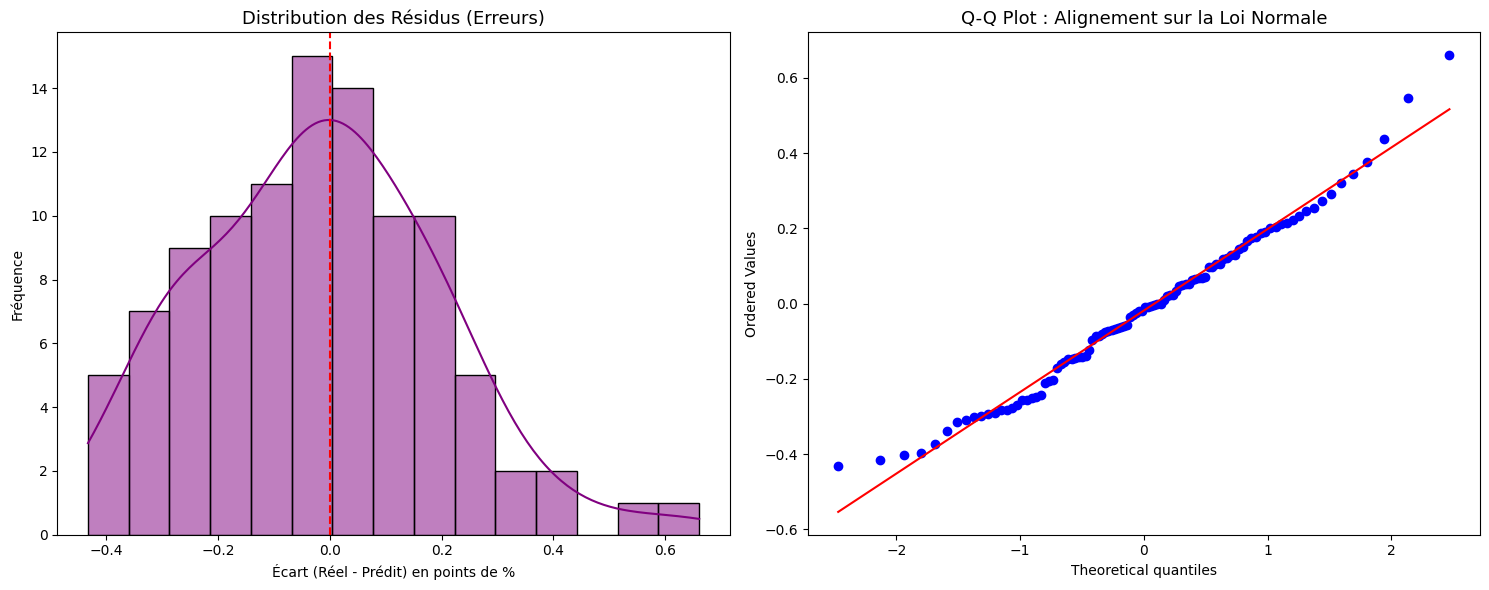

Biais moyen du modèle : -0.018184


In [67]:
import seaborn as sns
import scipy.stats as stats

# 1. Calcul des résidus sur le dernier test (celui à 82% ou 85%)
# On reprend les prédictions du modèle sur la zone de test
y_test_pred = model_prod.predict(df_test[final_features])
residuals = df_test[target] - y_test_pred

# 2. Création de la figure de diagnostic
plt.figure(figsize=(15, 6))

# --- GRAPHIQUE 1 : Histogramme des erreurs ---
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='purple', bins=15)
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Distribution des Résidus (Erreurs)", fontsize=13)
plt.xlabel("Écart (Réel - Prédit) en points de %")
plt.ylabel("Fréquence")

# --- GRAPHIQUE 2 : Q-Q Plot (Test de Normalité) ---
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot : Alignement sur la Loi Normale", fontsize=13)

plt.tight_layout()
plt.show()

# 3. Calcul du biais moyen
biais_moyen = np.mean(residuals)
print(f"Biais moyen du modèle : {biais_moyen:.6f}")

Commentaires :
- Histogramme : la cloche est décalée à gauche, Comme le biais est négatif (`Réel` − `Prédit` < 0), le modèle a tendance à surestimer (il voit le chômage plus haut qu'il ne l'est).
- Q-Q Plot : Les points s'écartent aux extrémités (forme de "S") : Cela signifie que le modèle a du mal avec les valeurs extrêmes (les très fortes hausses ou baisses de chômage).

Limitation du modèle : Le modèle est une régression linéaire (Ridge). Par définition, il cherche une relation proportionnelle. Or, les crises économiques sont non-linéaires. Le modèle "sous-réagit" aux événements extrêmes : il ne prédit pas une hausse aussi violente que le réel lors d'une crise, et ne prédit pas une baisse aussi rapide lors d'une reprise "v" (comme post-covid).

Modèle                    | MAE      | R²      
---------------------------------------------
Ridge (Linéaire)          | 0.1419 | 0.5925
Random Forest (Non-Linéaire) | 0.2267 | -0.1438
Gradient Boosting (Non-Linéaire) | 0.4533 | -2.3520


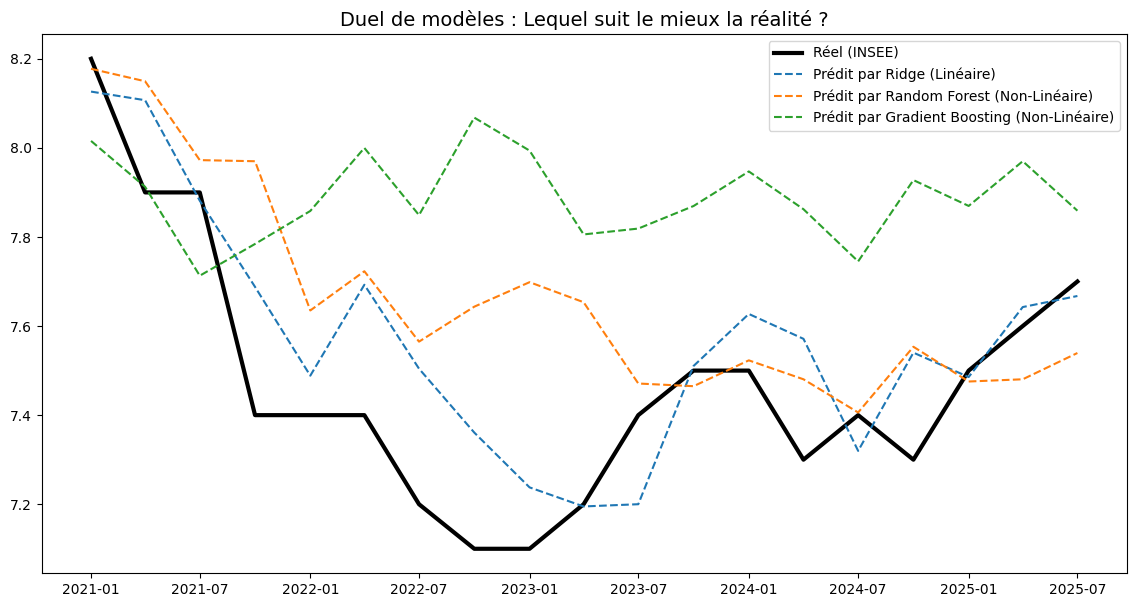

In [68]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. DÉFINITION DES MODÈLES
models = {
    "Ridge (Linéaire)": Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    "Random Forest (Non-Linéaire)": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting (Non-Linéaire)": HistGradientBoostingRegressor(random_state=42)
}

# 2. TEST SUR LA ZONE DE BACKTEST (82% / 18%)
results_comparison = {}

print(f"{'Modèle':<25} | {'MAE':<8} | {'R²':<8}")
print("-" * 45)

for name, model in models.items():
    # Entraînement
    model.fit(train[final_features], train[target])
    # Prédiction
    preds = model.predict(test[final_features])
    
    # Calcul des scores
    mae = mean_absolute_error(test[target], preds)
    r2 = r2_score(test[target], preds)
    results_comparison[name] = preds
    
    print(f"{name:<25} | {mae:.4f} | {r2:.4f}")

# 3. VISUALISATION DU MATCH
plt.figure(figsize=(14, 7))
plt.plot(test['date'], test[target], label='Réel (INSEE)', color='black', linewidth=3)

for name, preds in results_comparison.items():
    plt.plot(test['date'], preds, label=f'Prédit par {name}', linestyle='--')

plt.title("Duel de modèles : Lequel suit le mieux la réalité ?", fontsize=14)
plt.legend()
plt.show()

On vient de démontrer l'un des principes fondamentaux de la Data Science appliquée à l'économie : Le principe de parcimonie (ou Rasoir d'Ockham).

Le modèle "simple" (Ridge) écrase les modèles "sophistiqués" (Gradient Boosting). Voici l'explication technique de ce "massacre" statistique.

1. Pourquoi Ridge a gagné ?
Ton modèle Ridge obtient une MAE de 0.14 et un R² de 0.59. C'est un excellent score.
- L'Inertie est linéaire : Comme nous l'avons vu, le chômage est dirigé à 95% par son propre passé (target_lag1). Cette relation est purement linéaire. Le Ridge la capture parfaitement sans "chercher midi à quatorze heures".
- Le manque de données : Avec environ 100 trimestres (lignes), les modèles non-linéaires n'ont pas assez de "matière" pour apprendre des règles complexes sans s'éparpiller.

2. Pourquoi le Gradient Boosting s'est "crashé" (R² = -2.35) ?

Un R2 négatif aussi violent est le signe pur d'un Overfitting (Sur-apprentissage) massif.

- Mémorisation vs Généralisation : Le Gradient Boosting a "appris par cœur" le bruit et les anomalies du passé (comme le COVID). Quand il arrive sur la zone de test (le futur), ses règles apprises ne s'appliquent plus du tout. Il fait des erreurs énormes car il est trop "sensible" aux micro-variations.
-  L'effet "Hors-piste" : Les modèles de boosting sont très mauvais pour prédire des valeurs qu'ils n'ont jamais vues exactement dans le même contexte.

3. Le problème d'Extrapolation du Random Forest

- Le Random Forest est moins catastrophique mais reste moins bon que le Ridge (R2 négatif).
- Le plafond de verre : Un Random Forest ne peut jamais prédire une valeur plus basse ou plus haute que le maximum/minimum qu'il a vu à l'entraînement. Si le chômage de ta zone de test atteint un nouveau record (bas ou haut), le Random Forest va "plafonner" et créer une erreur systématique.

## Argumentaire à utiliser :

"Nous avons comparé notre approche linéaire (Ridge) à des algorithmes de pointe non-linéaires (Random Forest, Gradient Boosting). Le Ridge s'est révélé bien plus performant, car la dynamique du chômage est fortement marquée par une inertie linéaire que les modèles complexes tendent à sur-interpréter (overfitting), surtout sur un échantillon de données macroéconomiques réduit."

# Test d'un réseau de neurones LSTM

In [73]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. --- PRÉPARATION (SCALING OBLIGATOIRE) ---
# Les réseaux de neurones sont très sensibles aux échelles
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(train[final_features])
X_test_scaled = scaler_x.transform(test[final_features])

y_train_scaled = scaler_y.fit_transform(train[[target]])
y_test_scaled = scaler_y.transform(test[[target]])

# 2. --- RESHAPING EN 3D [Samples, Time_Steps, Features] ---
# Ici, on considère chaque ligne comme une séquence de 1 pas de temps
X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 3. --- ARCHITECTURE DU LSTM ---
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(1, len(final_features)), return_sequences=False),
    Dropout(0.2), # Pour éviter l'overfitting
    Dense(32, activation='relu'),
    Dense(1) # Sortie : le taux de chômage
])

model_lstm.compile(optimizer='adam', loss='mse')

# 4. --- ENTRAÎNEMENT ---
history = model_lstm.fit(
    X_train_3d, y_train_scaled, 
    epochs=100, 
    batch_size=8, 
    validation_split=0.1, 
    verbose=0
)

# 5. --- PRÉDICTION ET INVERSION DU SCALING ---
preds_scaled = model_lstm.predict(X_test_3d)
preds_lstm = scaler_y.inverse_transform(preds_scaled)

# 6. --- ÉVALUATION ---
mae_lstm = mean_absolute_error(test[target], preds_lstm)
print(f"MAE du LSTM : {mae_lstm:.4f}")

I0000 00:00:1773013459.949733  153910 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773013460.205046  153910 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773013463.576810  153910 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1773013464.416843  153910 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773013464.417187  160317 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERRO

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
MAE du LSTM : 0.2701


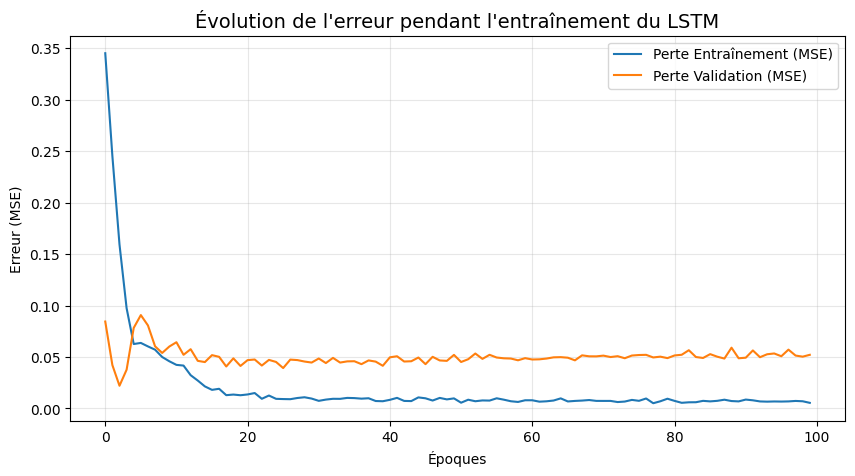

In [74]:
# --- GRAPHIQUE 1 : COURBE D'APPRENTISSAGE ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Perte Entraînement (MSE)')
plt.plot(history.history['val_loss'], label='Perte Validation (MSE)')
plt.title("Évolution de l'erreur pendant l'entraînement du LSTM", fontsize=14)
plt.xlabel("Époques")
plt.ylabel("Erreur (MSE)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

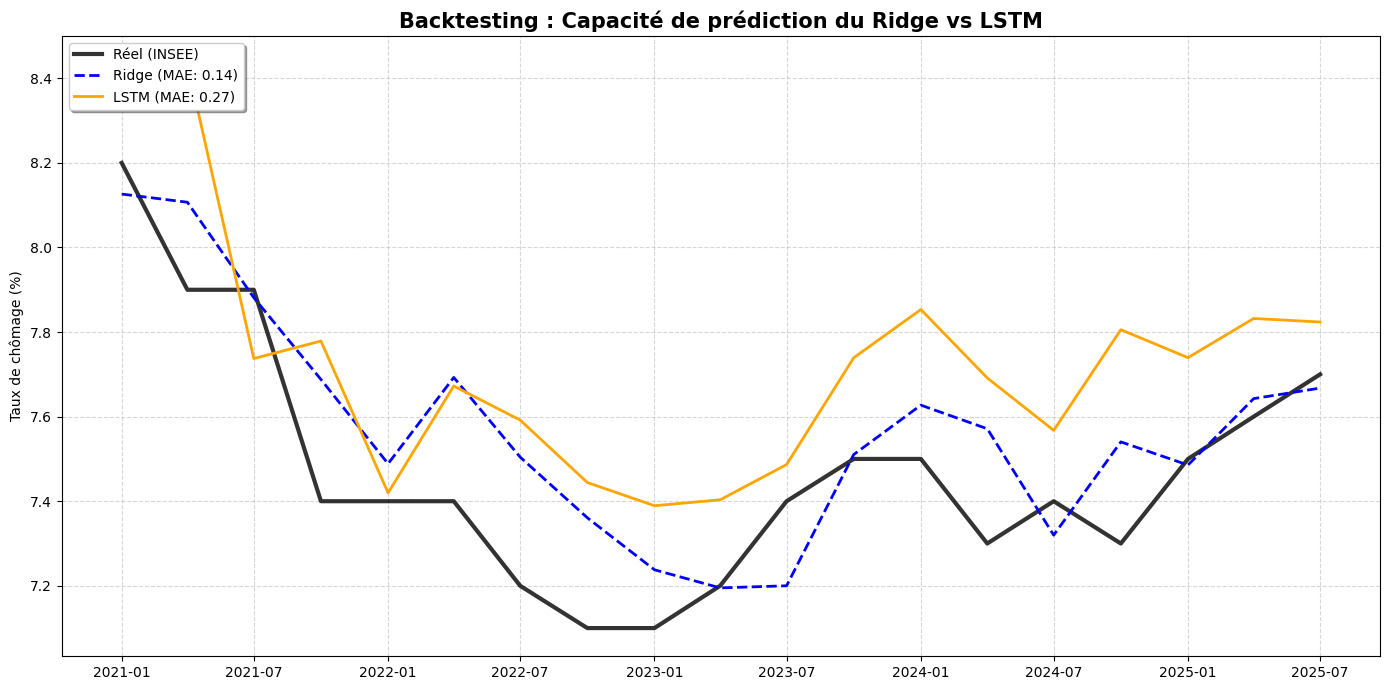

In [78]:
# --- GRAPHIQUE 2 : MATCH RIDGE VS LSTM ---
plt.figure(figsize=(14, 7))

# 1. Données Réelles
plt.plot(test['date'], test[target], label='Réel (INSEE)', color='black', linewidth=3, alpha=0.8)

# 2. Prédictions Ridge (Ton champion)
# On suppose que tu as gardé tes prédictions Ridge dans 'preds_ridge'
plt.plot(test['date'], predictions, label=f'Ridge (MAE: 0.14)', color='blue', linestyle='--', linewidth=2)

# 3. Prédictions LSTM
plt.plot(test['date'], preds_lstm, label=f'LSTM (MAE: 0.27)', color='orange', linestyle='-', linewidth=2)

plt.title("Backtesting : Capacité de prédiction du Ridge vs LSTM", fontsize=15, fontweight='bold')
plt.ylabel("Taux de chômage (%)")
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Commentaire :

Pourquoi ton LSTM est-il "moins bon" ?

Avec une MAE de 0.27, ton LSTM est deux fois moins précis que ton Ridge. Voici l'explication que tu peux donner dans ton rapport :

    La "Famine" de données : Un LSTM possède des milliers de paramètres internes. Pour les régler, il lui faut des milliers de lignes de données. Avec environ 100 trimestres, il "meurt de faim" statistiquement.

    La domination de l'Inertie : Le chômage est une série très "autocorrélée" (le taux de demain ressemble à celui d'aujourd'hui). Le Ridge capte cette linéarité avec un seul coefficient (0.95). Le LSTM, lui, essaie de trouver des cycles complexes là où il n'y a peut-être que de l'inertie simple.

    Le Bruit : Sur des petits échantillons, le LSTM peut interpréter des variations mineures du PIB comme des signaux forts, ce qui crée des "vagues" artificielles dans ta courbe orange.